In [10]:
# Load
import pandas as pd
from run_xgb_profile_prediction import DEFAULT_CONFIG, MorphologyData

# Profiles
morphology_data = MorphologyData(**DEFAULT_CONFIG)

# Predictions
prediction_dfs = {
    group: pd.read_parquet(f'results/XGB Predictions {group} 2024-06-11.parquet')
    for group in ('Abundance', 'GO', 'SC', 'GO+Abundance', 'GO+SC')
}

/scratch/yuriy/morphology-prediction/skl-models/run_xgb_profile_prediction.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abundance_df.loc[:, 'Protein present'] = 1


In [11]:
# Total sum of squares in profiles
profile_tss = (
    (
        morphology_data.well_features_and_profiles[morphology_data.profile_columns]
        - morphology_data.well_features_and_profiles[morphology_data.profile_columns].mean(axis='index')
    ) ** 2
).sum(axis='index')

# Compute R squared
xgb_rsquared = pd.concat(
    {
        name:
            1 - ((df - morphology_data.well_features_and_profiles[morphology_data.profile_columns])**2).sum(axis='index') / profile_tss
        for name, df in prediction_dfs.items()
    },
    names = ['Group']
)

In [12]:
rsquared_df = xgb_rsquared.sort_values(ascending=False).to_frame(name='R Squared')
rsquared_df.index.set_names(['Group', 'Feature'], inplace=True)
rsquared_df.reset_index(inplace=True)

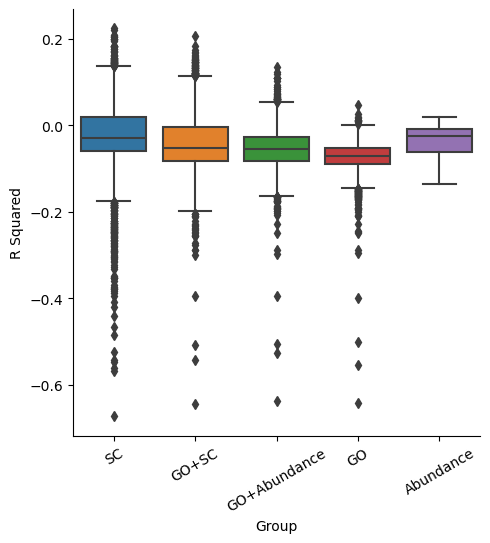

In [13]:
import seaborn as sns

g = sns.catplot(
    data=rsquared_df,
    x='Group',
    y='R Squared',
    kind='box',
    facet_kws={'margin_titles': True}
)
g.set_xticklabels(rotation=30)